# NEST Simulation from SONATA

This notebook demonstrates how to:
1. Generate a SONATA simulation campaign for a NEST circuit using `NestCircuitSimulationScanConfig`
2. Run the simulation using the NEST simulator via `NestSimulationFromSonataTask`
3. Load and plot the results

**Prerequisites:**
- `nest-simulator` (install via conda-forge: `mamba install -c conda-forge nest-simulator`)
- Run one of the conversion notebooks first:
  - `convert_new_allen_v1_to_libsonata_compatible.ipynb` for Allen V1 (core_nll_7)
  - `convert_fly_brain_to_libsonata_compatible.ipynb` for FlyWire Drosophila

In [1]:
import json
from pathlib import Path

# --- Choose circuit ---
CIRCUIT = "fly_brain"  # Options: "allen_v1", "fly_brain"

CIRCUITS = {
    "allen_v1": {
        "circuit_dir": Path("../../../obi-output/circuit/nest_core_nll_7"),
        "output_root": Path("../../../obi-output/simulation/nest_core_nll_7"),
        "name": "core_nll_7",
        "population": "v1",
    },
    "fly_brain": {
        "circuit_dir": Path("../../../obi-output/circuit/nest_fly_brain"),
        "output_root": Path("../../../obi-output/simulation/nest_fly_brain"),
        "name": "fly_brain",
        "population": "fly",
    },
}

cfg = CIRCUITS[CIRCUIT]
CIRCUIT_DIR = cfg["circuit_dir"]
circuit_config_path = CIRCUIT_DIR / "circuit_config.json"
OUTPUT_ROOT = cfg["output_root"]
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Circuit: {cfg['name']} (population: {cfg['population']})")

Circuit: fly_brain (population: fly)


## 1. Generate the SONATA simulation campaign

Use `NestCircuitSimulationScanConfig` with the selected circuit.
This restricts blocks to NEST-compatible types and produces a
`simulation_config.json` with `target_simulator: "NEST"`.

In [2]:
from obi_one.core.info import Info
from obi_one.scientific.blocks.neuron_sets.specific import AllNeurons
from obi_one.scientific.blocks.recording import SomaVoltageRecording
from obi_one.scientific.blocks.stimuli.stimulus import NormallyDistributedCurrentClampSomaticStimulus
from obi_one.scientific.blocks.timestamps.single import SingleTimestamp
from obi_one.scientific.library.circuit import Circuit
from obi_one.scientific.tasks.generate_simulations.config.nest_circuit import (
    NestCircuitSimulationScanConfig,
)

In [ ]:
import numpy as np

SIM_LENGTH_MS = 500.0

circuit = Circuit(name=cfg["name"], path=str(circuit_config_path.absolute()))
pop_name = cfg["population"]
print(f"Circuit loaded: {pop_name} ({circuit.sonata_circuit.nodes[pop_name].size} neurons)")

sim_conf = NestCircuitSimulationScanConfig.empty_config()

# Info
info = Info(
    campaign_name=f"NEST {cfg['name']} demo",
    campaign_description=f"{SIM_LENGTH_MS:.0f} ms NEST simulation of {cfg['name']}",
)
sim_conf.set(info, name="info")

# Timestamps
stim_time = SingleTimestamp(start_time=10.0)
sim_conf.add(stim_time, name="stim_onset")

# Neuron sets
all_neurons = AllNeurons()
sim_conf.add(all_neurons, name="AllNeurons")

mean_amplitude = [0.0002, 0.0003, 0.0004, 0.0005]

# Stimulus: constant current
current_stim = NormallyDistributedCurrentClampSomaticStimulus(
    timestamps=stim_time.ref,
    neuron_set=all_neurons.ref,
    mean_amplitude=mean_amplitude,  # nA
    variance=(0.2*np.asarray(mean_amplitude)).tolist(),
    timestamp_offset=50.0,
    duration=500.0,
)
sim_conf.add(current_stim, name="ConstantCurrent")

# Recording: soma voltage for the full simulation
voltage_rec = SomaVoltageRecording(
    neuron_set=all_neurons.ref,
    dt=1.0,
)
# sim_conf.add(voltage_rec, name="SomaVoltage")

# Initialize
initialize = NestCircuitSimulationScanConfig.Initialize(
    circuit=circuit,
    node_set=all_neurons.ref,
    simulation_length=SIM_LENGTH_MS,
    v_init=-70.0,
)
sim_conf.set(initialize, name="initialize")

validated = sim_conf.validated_config()
print("Config validated.")

Circuit loaded: fly (138639 neurons)
Config validated.


In [4]:
from obi_one.core.run_tasks import run_task_for_single_configs
# from obi_one.core.scan_generation import GridScanGenerationTask
from obi_one.core.scan_generation import CoupledScanGenerationTask

campaign_dir = str(OUTPUT_ROOT / "campaign")
grid_scan = CoupledScanGenerationTask(form=validated, output_root=campaign_dir)
grid_scan.multiple_value_parameters(display=True)
grid_scan.execute()

# Run GenerateSimulationTask for each coordinate to produce simulation_config.json
run_task_for_single_configs(single_configs=grid_scan.single_configs)

single_configs = grid_scan.single_configs
coord_roots = [Path(sc.coordinate_output_root) for sc in single_configs]
print(f"\nGenerated {len(single_configs)} simulation coordinate(s)")

# Inspect the first coordinate's simulation_config.json
sim_config_path = coord_roots[0] / "simulation_config.json"
print(f"First simulation config: {sim_config_path}")

[2026-04-01 23:31:11,973] INFO: 
MULTIPLE VALUE PARAMETERS
[2026-04-01 23:31:11,973] INFO: stimuli.ConstantCurrent.mean_amplitude: [5e-05, 0.0001, 0.0005]
[2026-04-01 23:31:11,973] INFO: stimuli.ConstantCurrent.variance: [1e-05, 2e-05, 0.0001]
[2026-04-01 23:31:11,978] INFO: initialize.circuit is a Circuit instance.
[2026-04-01 23:31:12,052] INFO: initialize.circuit is a Circuit instance.
[2026-04-01 23:31:12,115] INFO: initialize.circuit is a Circuit instance.

Generated 3 simulation coordinate(s)
First simulation config: ../../../obi-output/simulation/nest_fly_brain/campaign/stimuli.ConstantCurrent.mean_amplitude=5e-05/stimuli.ConstantCurrent.variance=1e-05/simulation_config.json


In [5]:
with sim_config_path.open() as f:
    generated_config = json.load(f)

print(f"target_simulator: {generated_config['target_simulator']}")
print(f"tstop: {generated_config['run']['tstop']} ms")
print(f"inputs: {list(generated_config.get('inputs', {}).keys())}")
print(f"reports: {list(generated_config.get('reports', {}).keys())}")

target_simulator: NEST
tstop: 200.0 ms
inputs: ['ConstantCurrent_0']
reports: []


## 2. Run the NEST simulation

Feed the generated `simulation_config.json` to `NestSimulationFromSonataTask`.

In [6]:
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

In [7]:
from obi_one.core.path import NamedPath
from obi_one.scientific.tasks.nest_simulation_from_sonata.config import (
    NestSimulationFromSonataSingleConfig,
)
from obi_one.scientific.tasks.nest_simulation_from_sonata.task import (
    NestSimulationFromSonataTask,
)

for i, coord_root in enumerate(coord_roots):
    sc_sim_config = coord_root / "simulation_config.json"
    print(f"--- Coordinate {i + 1}/{len(coord_roots)}: {coord_root.name} ---")

    nest_run_config = NestSimulationFromSonataSingleConfig.empty_config()
    nest_init = NestSimulationFromSonataSingleConfig.Initialize(
        simulation_config_path=NamedPath(
            name=f"{cfg['name']} generated config",
            path=str(sc_sim_config.absolute()),
        ),
        nest_model="iaf_psc_alpha",
    )
    nest_run_config.set(nest_init, name="initialize")
    nest_run_config.scan_output_root = str(coord_root)
    nest_run_config.coordinate_output_root = str(coord_root)

    task = NestSimulationFromSonataTask(config=nest_run_config)
    task.execute()

--- Coordinate 1/3: stimuli.ConstantCurrent.variance=1e-05 ---

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Oct  2 2025 07:09:22

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


Apr 01 23:31:12 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.025 ms.
[2026-04-01 23:31:12,354] INFO: Population 'fly': model_template='iaf_psc_exp', dynamics_params=['C_m', 'E_L', 'I_e', 'V_m', 'V_reset', 'V_th', 't_ref', 'tau_m', 'tau_syn_ex', 'tau_syn_in']
[2026-04-01 23:31:13,071] INFO: Created 138639 NEST neurons for population 'fly' (type=point_process, model=iaf_psc_exp)
[2026-04-01 23:31:19,136] INFO: Connected 15091983 edges: fly -> fly
[2026-04-01 23:31:19,919] INFO: Applied input 'ConstantCurrent_0' (module=noise)
[2026-04-01 23:31:20,504] INFO: Star

## 3. Analyze results

In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

=== stimuli.ConstantCurrent.variance=1e-05 ===
Population 'fly': 0 spikes from 0 neurons


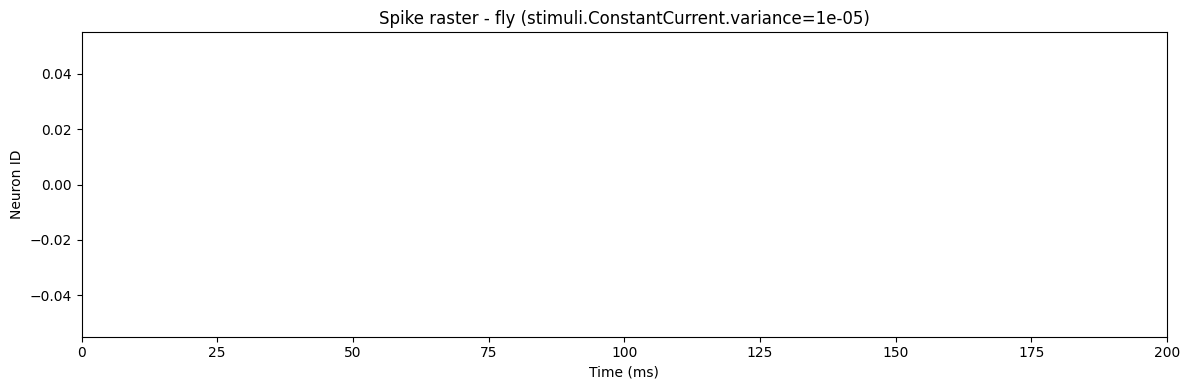

=== stimuli.ConstantCurrent.variance=2e-05 ===
Population 'fly': 0 spikes from 0 neurons


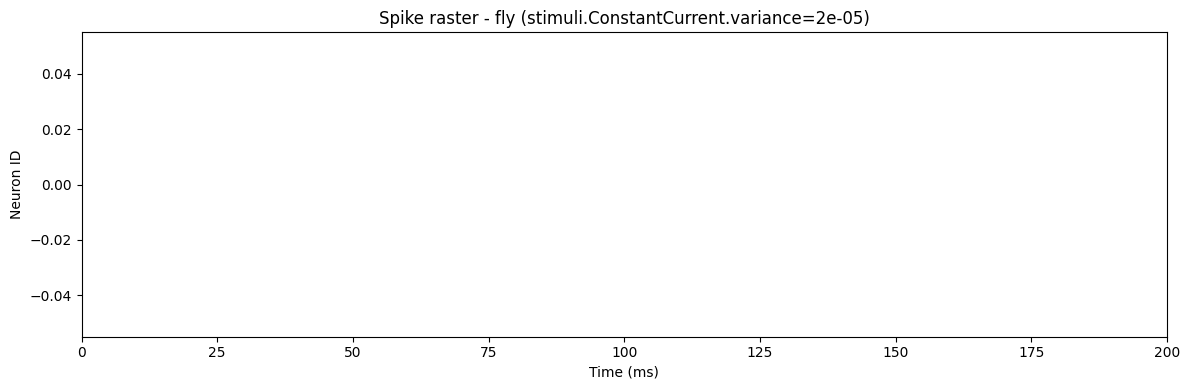

=== stimuli.ConstantCurrent.variance=0.0001 ===
Population 'fly': 2417 spikes from 1068 neurons


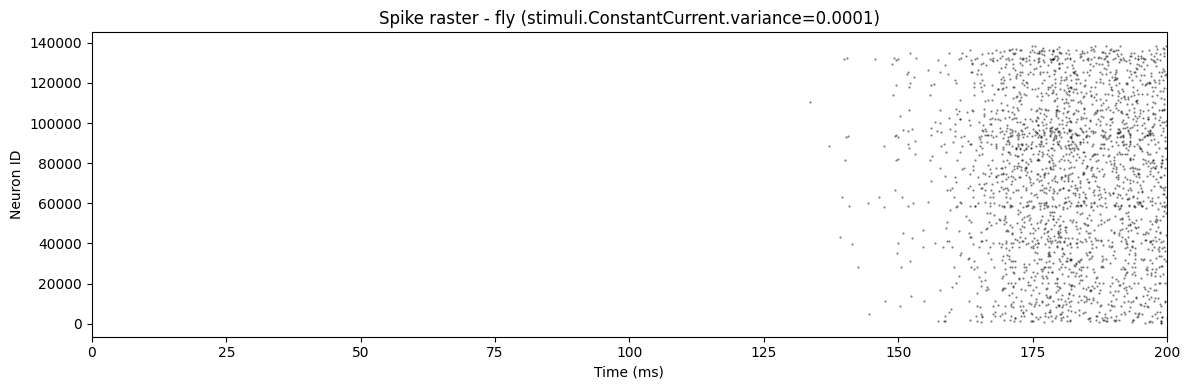

In [9]:
for coord_root in coord_roots:
    spike_file = coord_root / "nest_output" / "spikes.h5"
    if not spike_file.exists():
        print(f"No spike output for {coord_root.name}")
        continue

    print(f"=== {coord_root.name} ===")
    with h5py.File(spike_file, "r") as f:
        for pop_name in f["spikes"]:
            timestamps = f["spikes"][pop_name]["timestamps"][:]
            node_ids = f["spikes"][pop_name]["node_ids"][:]
            n_unique = len(np.unique(node_ids))
            print(f"Population '{pop_name}': {len(timestamps)} spikes from {n_unique} neurons")

            fig, ax = plt.subplots(figsize=(12, 4))
            ax.scatter(timestamps, node_ids, s=0.3, alpha=0.5, c="black")
            ax.set_xlabel("Time (ms)")
            ax.set_ylabel("Neuron ID")
            ax.set_title(f"Spike raster - {pop_name} ({coord_root.name})")
            ax.set_xlim(0, SIM_LENGTH_MS)
            # ax.set_ylim(0, 100)
            plt.tight_layout()
            plt.show()

In [10]:
for coord_root in coord_roots:
    voltage_file = coord_root / "nest_output" / "voltage.h5"
    if not voltage_file.exists():
        continue

    print(f"=== {coord_root.name} ===")
    with h5py.File(voltage_file, "r") as f:
        for report_name in f["reports"]:
            grp = f["reports"][report_name]
            senders = grp["senders"][:]
            timestamps = grp["timestamps"][:]
            data = grp["data"][:]

            unique_neurons = np.unique(senders)[:5]
            fig, ax = plt.subplots(figsize=(12, 4))
            for nid in unique_neurons:
                mask = senders == nid
                ax.plot(timestamps[mask], data[mask], label=f"Neuron {nid}", alpha=0.8)
            ax.set_xlabel("Time (ms)")
            ax.set_ylabel("Membrane potential (mV)")
            ax.set_title(f"Voltage traces - {report_name} ({coord_root.name})")
            ax.legend(loc="upper right", fontsize=8)
            plt.tight_layout()
            plt.show()

In [11]:
for coord_root in coord_roots:
    spike_file = coord_root / "nest_output" / "spikes.h5"
    if not spike_file.exists():
        continue

    with h5py.File(spike_file, "r") as f:
        for pop_name in f["spikes"]:
            timestamps = f["spikes"][pop_name]["timestamps"][:]
            node_ids = f["spikes"][pop_name]["node_ids"][:]

            # Per-neuron spike count → mean firing rate (Hz)
            unique_ids, counts = np.unique(node_ids, return_counts=True)
            sim_duration_s = SIM_LENGTH_MS / 1000.0
            rates = counts / sim_duration_s

            n_total = circuit.sonata_circuit.nodes[cfg["population"]].size
            n_silent = n_total - len(unique_ids)
            all_rates = np.concatenate([rates, np.zeros(n_silent)])

            print(f"=== {coord_root.name} / {pop_name} ===")
            print(f"  Active neurons: {len(unique_ids):,} / {n_total:,} ({100*len(unique_ids)/n_total:.1f}%)")
            print(f"  Total spikes: {len(timestamps):,}")
            print(f"  Mean rate (active only): {rates.mean():.1f} Hz")
            print(f"  Mean rate (all neurons): {all_rates.mean():.1f} Hz")
            print(f"  Max rate: {rates.max():.1f} Hz")

            fig, axes = plt.subplots(1, 2, figsize=(14, 4))

            # Histogram of firing rates (active neurons only)
            axes[0].hist(rates, bins=50, edgecolor="black", linewidth=0.3)
            axes[0].set_xlabel("Firing rate (Hz)")
            axes[0].set_ylabel("Neuron count")
            axes[0].set_title(f"Firing rate distribution — active neurons ({coord_root.name})")
            axes[0].axvline(rates.mean(), color="red", linestyle="--", label=f"mean={rates.mean():.1f} Hz")
            axes[0].legend()

            # Log-scale histogram including silent neurons
            axes[1].hist(all_rates, bins=50, edgecolor="black", linewidth=0.3)
            axes[1].set_xlabel("Firing rate (Hz)")
            axes[1].set_ylabel("Neuron count")
            axes[1].set_yscale("log")
            axes[1].set_title(f"Firing rate distribution — all neurons ({coord_root.name})")
            axes[1].axvline(all_rates.mean(), color="red", linestyle="--", label=f"mean={all_rates.mean():.1f} Hz")
            axes[1].legend()

            plt.tight_layout()
            plt.show()

=== stimuli.ConstantCurrent.variance=1e-05 / fly ===
  Active neurons: 0 / 138,639 (0.0%)
  Total spikes: 0
  Mean rate (active only): nan Hz
  Mean rate (all neurons): 0.0 Hz


/var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/ipykernel_8571/753725932.py:23: RuntimeWarning:Mean of empty slice.
/Users/james/Documents/obi/code/obi-main/obi-one/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning:invalid value encountered in scalar divide


ValueError: zero-size array to reduction operation maximum which has no identity